# Анализ обращений в службу поддержки

## Взаимосвязи, статистические гипотезы и прогнозирование нагрузки

В этой практической работе вы пройдёте полный аналитический цикл:

1. проверите рабочую среду и исходные файлы;
2. загрузите и очистите данные;
3. объедините несколько таблиц;
4. исследуете взаимосвязи между показателями;
5. проверите статистические гипотезы;
6. подготовите временной ряд;
7. сравните базовые прогнозы и ARIMA;
8. сохраните таблицы, метрики и графики.

Данные синтетические и не содержат реальных персональных данных.

## Ожидаемый результат

После выполнения notebook в папке `outputs` должны появиться:

- `support_analysis_dataset.csv` — очищенная объединённая таблица;
- `channel_summary.csv` — показатели по каналам;
- `hypothesis_results.csv` — результаты статистических тестов;
- `daily_tickets.csv` — дневной временной ряд;
- `forecast_metrics.csv` — сравнение прогнозов;
- `forecast_values.csv` — фактические и прогнозные значения;
- папка `figures` с основными графиками.

Работайте последовательно: выполняйте ячейки сверху вниз.

In [1]:
# Устанавливаем все библиотеки и зависимости, перечисленные в requirements.txt

%pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not open requirements file: [Errno 2] No such file or directory: 'requirements.txt'
You should consider upgrading via the 'c:\Users\ADMIN\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.


In [2]:
# Проверяем версию Matplotlib в текущем окружении.
# Это полезно при диагностике несовместимости API между версиями библиотеки.
# Например, некоторые параметры графиков могли быть переименованы в новых версиях.

import matplotlib

print(matplotlib.__version__)

3.7.1


## 1. Проверка рабочей среды

Notebook может быть открыт как из корня проекта, так и из папки `notebooks`. Следующая ячейка автоматически найдёт корень проекта по расположению исходных CSV-файлов.

In [3]:
# Подготавливаем пути проекта так, чтобы notebook не зависел от конкретного имени пользователя, диска или абсолютного пути на компьютере.
# Функция ниже ищет корень проекта по контрольному файлу support_tickets.csv.

from pathlib import Path
import sys


def find_project_root(start: Path | None = None) -> Path:
    # start позволяет при необходимости передать начальную папку вручную.
    # Если start не указан, поиск начинается из текущей рабочей директории.
    """Найти корень проекта без абсолютных путей пользователя."""
    current = (start or Path.cwd()).resolve()
    # Проверяем текущую папку и всех её родителей.
    # Благодаря этому notebook можно запускать как из корня проекта, так и из вложенной папки notebooks.
    candidates = [current, *current.parents]

    for candidate in candidates:
    # Контрольным признаком корня проекта считаем наличие data/raw/support_tickets.csv.
        expected = candidate / "data" / "raw" / "support_tickets.csv"
        if expected.exists():
            return candidate

    raise FileNotFoundError(
        "Не найден корень проекта. Проверьте, что папка data/raw содержит "
        "support_tickets.csv, customers.csv и regions.csv."
    )


PROJECT_ROOT = find_project_root()
RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
FIGURES_DIR = OUTPUT_DIR / "figures"

# Создаём каталоги для результатов, если их ещё нет.
# parents=True создаёт недостающие родительские папки,
# exist_ok=True не вызывает ошибку при повторном запуске notebook.
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Python:", sys.version.split()[0])
print("Корень проекта:", PROJECT_ROOT)
print("Папка исходных данных:", RAW_DIR)
print("Папка результатов:", OUTPUT_DIR)

Python: 3.10.5
Корень проекта: D:\Андрей\РАБОТА ФИН.УНИВЕР. ПРЕПОД\Занятие 7 15.08.2026\Аудиторные материалы\Тема Основы статистического анализа данных\01_statistics\support_service_case
Папка исходных данных: D:\Андрей\РАБОТА ФИН.УНИВЕР. ПРЕПОД\Занятие 7 15.08.2026\Аудиторные материалы\Тема Основы статистического анализа данных\01_statistics\support_service_case\data\raw
Папка результатов: D:\Андрей\РАБОТА ФИН.УНИВЕР. ПРЕПОД\Занятие 7 15.08.2026\Аудиторные материалы\Тема Основы статистического анализа данных\01_statistics\support_service_case\outputs


### Проверка файлов

Все три исходных файла должны получить статус `OK`. Если отображается `НЕ НАЙДЕН`, проверьте структуру распакованной папки.

In [4]:
# Формируем словарь обязательных исходных файлов.
# Ключ словаря — понятное человеку название набора данных,
# значение — полный путь к файлу внутри папки data/raw.
# Далее проверяем существование каждого файла до начала анализа.

required_files = {
    "Обращения": RAW_DIR / "support_tickets.csv",
    "Клиенты": RAW_DIR / "customers.csv",
    "Регионы": RAW_DIR / "regions.csv",
}

# Флаг останется True только в том случае, если найдены все файлы.
all_files_found = True
for label, file_path in required_files.items():
    if file_path.exists():
        print(f"OK: {label}: {file_path.name}")
    else:
        all_files_found = False
        print(f"НЕ НАЙДЕН: {label}: {file_path}")

# assert намеренно останавливает дальнейший анализ при отсутствии данных:
# лучше получить понятную ошибку сейчас, чем неверные результаты позже.
assert all_files_found, "Не все исходные файлы найдены. Исправьте структуру папок."

OK: Обращения: support_tickets.csv
OK: Клиенты: customers.csv
OK: Регионы: regions.csv


## 2. Импорт библиотек

Для основной работы нужны `pandas`, `numpy`, `matplotlib` и `scipy`. Библиотека `statsmodels` используется в дополнительном блоке ARIMA.

In [5]:
# Импортируем библиотеки, которые будут использоваться в основном анализе.
# pandas — работа с таблицами, NumPy — численные вычисления,
# matplotlib — визуализация, scipy.stats — статистические тесты.

import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

# Скрываем FutureWarning, чтобы учебный вывод не перегружался предупреждениями
# о будущих изменениях API. Реальные ошибки при этом не скрываются.
warnings.filterwarnings("ignore", category=FutureWarning)

# Настраиваем отображение таблиц: показываем до 50 столбцов
# и выводим числа с тремя знаками после запятой.
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")

print("pandas:", pd.__version__)
print("numpy:", np.__version__)

pandas: 2.0.1
numpy: 1.23.5


## 3. Загрузка данных

CSV-файлы используют кодировку UTF-8 with BOM. `pandas` обычно распознаёт её автоматически; параметр `encoding="utf-8-sig"` указан явно для воспроизводимости.

In [6]:
# Загружаем три исходные таблицы из CSV.
# encoding='utf-8-sig' явно задаёт кодировку UTF-8 with BOM,
# чтобы кириллица корректно читалась в разных операционных системах.
# Суффикс _raw подчёркивает, что это исходные данные без изменений.

tickets_raw = pd.read_csv(
    RAW_DIR / "support_tickets.csv",
    encoding="utf-8-sig",
)
customers_raw = pd.read_csv(
    RAW_DIR / "customers.csv",
    encoding="utf-8-sig",
)
regions_raw = pd.read_csv(
    RAW_DIR / "regions.csv",
    encoding="utf-8-sig",
)

# shape возвращает пару (число строк, число столбцов).
# Это первая контрольная проверка объёма загруженных таблиц.
print("support_tickets:", tickets_raw.shape)
print("customers:", customers_raw.shape)
print("regions:", regions_raw.shape)

# head() показывает первые пять строк и помогает быстро проверить,
# что столбцы и значения прочитались ожидаемым образом.
display(tickets_raw.head())
display(customers_raw.head())
display(regions_raw.head())

support_tickets: (1510, 11)
customers: (330, 5)
regions: (8, 4)


,ticket_id,created_at,customer_id,region_id,channel,category,priority,first_response_min,resolution_hours,sla_breached,satisfaction_score
0,TCK-000907,2026-03-31 17:13:00,CUST-0204,R02,chat,technical,normal,1.000,34.700,1,3.800
1,TCK-000618,2026-05-07 21:14:00,CUST-0073,R01,web_form,delivery,normal,38.900,12.200,0,4.300
2,TCK-000939,2026-05-08 08:20:00,CUST-0043,R02,chat,account,low,3.900,3.800,0,5.000
3,TCK-000941,2026-05-08 16:31:00,CUST-0071,R01,chat,login,normal,3.500,4.000,0,4.500
4,TCK-000304,2026-04-18 19:00:00,CUST-0230,R06,web_form,technical,normal,50.500,21.900,1,3.300


,customer_id,segment,registration_date,loyalty_level,is_premium
0,CUST-0001,b2b,2024-05-19,gold,0
1,CUST-0002,b2c,2025-08-03,bronze,0
2,CUST-0003,b2b,2024-01-28,gold,0
3,CUST-0004,b2b,2024-06-08,silver,0
4,CUST-0005,b2c,2025-04-16,bronze,0


,region_id,region_name,macro_region,support_team
0,R01,Москва,Центр,team_a
1,R02,Санкт-Петербург,Северо-Запад,team_b
2,R03,Казань,Поволжье,team_c
3,R04,Екатеринбург,Урал,team_d
4,R05,Новосибирск,Сибирь,team_e


### Контрольная точка

Убедитесь, что:

- основная таблица содержит больше 1 000 строк;
- справочник клиентов содержит несколько сотен строк;
- справочник регионов содержит 8 строк;
- названия столбцов соответствуют описанию данных.

## 4. Первичная диагностика качества данных

На этом этапе данные не изменяются. Мы фиксируем исходное состояние: типы, пропуски, дубли и диапазоны числовых показателей.

In [7]:
# Выполняем первичную диагностику основной таблицы без изменения данных.
# На этом этапе важно понять структуру, объём пропусков, наличие повторов
# и диапазоны числовых показателей до принятия решений по очистке.

print("Типы данных в support_tickets:")
# dtypes показывает тип каждого столбца. Ошибочные типы особенно важны
# для дат, числовых полей и логических признаков.
display(tickets_raw.dtypes.to_frame("dtype"))

print("Пропуски в support_tickets:")
# isna().sum() считает количество пропущенных значений по каждому столбцу.
display(tickets_raw.isna().sum().to_frame("missing_count"))

# ticket_id должен однозначно идентифицировать обращение.
# duplicated().sum() показывает количество повторных идентификаторов.
print("Повторные ticket_id:", tickets_raw["ticket_id"].duplicated().sum())

print("Описательные статистики:")
# describe() даёт count, mean, std, квартили, минимум и максимум
# для выбранных числовых показателей.
display(
    tickets_raw[
        ["first_response_min", "resolution_hours", "satisfaction_score"]
    ].describe()
)

Типы данных в support_tickets:


,dtype
ticket_id,object
created_at,object
customer_id,object
region_id,object
channel,object
category,object
priority,object
first_response_min,float64
resolution_hours,float64
sla_breached,int64


Пропуски в support_tickets:


,missing_count
ticket_id,0
created_at,0
customer_id,0
region_id,20
channel,0
category,0
priority,0
first_response_min,0
resolution_hours,0
sla_breached,0


Повторные ticket_id: 10
Описательные статистики:


,first_response_min,resolution_hours,satisfaction_score
count,"1,510.000","1,510.000","1,450.000"
mean,21.541,20.358,4.134
std,26.615,25.287,0.872
min,-9.000,0.500,1.000
25%,4.600,6.725,3.700
50%,10.950,13.350,4.300
75%,27.550,25.300,4.900
max,190.600,256.100,5.000


### Диагностика категорий

Разный регистр и лишние пробелы создают ложные категории. Сначала посмотрим исходные значения, затем выполним нормализацию.

In [8]:
# Проверяем фактические значения категориальных признаков.
# dropna=False специально оставляет пропуски в подсчёте,
# чтобы они не исчезали из диагностики качества данных.

# Проходим по трём категориальным полям одним циклом,
# чтобы не дублировать одинаковый код для каждого столбца.
for column in ["channel", "category", "priority"]:
    print(f"\nИсходные значения {column}:")
    display(tickets_raw[column].value_counts(dropna=False).to_frame("count"))


Исходные значения channel:


,count
channel,
chat,544
email,449
phone,266
web_form,221
WEB_FORM,10
EMAIL,8
Chat,6
Phone,6



Исходные значения category:


,count
category,
technical,378
delivery,265
payment,260
login,213
account,206
refund,158
Refund,10
technical,9
PAYMENT,6



Исходные значения priority:


,count
priority,
normal,828
high,326
low,246
critical,110


### Диагностика бизнес-правил

Время первого ответа не должно быть нулевым или отрицательным. Очень большое время решения не удаляется автоматически: такие значения сначала нужно исследовать как возможные выбросы или реальные сложные обращения.

In [9]:
# Собираем ключевые показатели качества в один объект Series.
# Такой снимок удобно использовать как контрольную точку:
# мы фиксируем состояние исходных данных до очистки и преобразований.

quality_snapshot = pd.Series({
    # Общее количество строк позволяет затем оценить эффект очистки.
    "rows": len(tickets_raw),
    # nunique() считает число уникальных обращений.
    "unique_ticket_ids": tickets_raw["ticket_id"].nunique(),
    # Повторы идентификатора могут привести к двойному учёту обращения.
    "duplicate_ticket_rows": tickets_raw["ticket_id"].duplicated().sum(),
    "missing_satisfaction": tickets_raw["satisfaction_score"].isna().sum(),
    "missing_region": tickets_raw["region_id"].isna().sum(),
    # Нулевое/отрицательное время первого ответа нарушает бизнес-правило.
    "nonpositive_first_response": (tickets_raw["first_response_min"] <= 0).sum(),
    # Очень большие значения не удаляем, а только считаем для последующего анализа.
    "resolution_over_140h": (tickets_raw["resolution_hours"] > 140).sum(),
})

display(quality_snapshot.to_frame("value"))

,value
rows,1510
unique_ticket_ids,1500
duplicate_ticket_rows,10
missing_satisfaction,60
missing_region,20
nonpositive_first_response,5
resolution_over_140h,15


### Самостоятельный мини-анализ

Ответьте в новой Markdown-ячейке:

1. Какие проблемы качества критичны для расчёта корреляции?
2. Какие проблемы критичны для сравнения регионов?
3. Почему нельзя удалить все строки с любой проблемой одной командой `dropna()`?

## 5. Очистка и подготовка данных

Создаём копии исходных таблиц, чтобы сохранить необработанные данные. Решения по очистке:

- даты преобразуем в `datetime`;
- категории нормализуем через удаление пробелов и нижний регистр;
- повторные `ticket_id` удаляем, оставляя первую запись;
- значения `first_response_min <= 0` заменяем на `NaN`;
- выбросы `resolution_hours` сохраняем для дальнейшего сравнения;
- пропуски оценки не заполняем искусственно.

In [10]:
# Создаём рабочие копии исходных таблиц.
# Это важный принцип воспроизводимого анализа: *_raw остаются неизменными,
# а все преобразования выполняются над отдельными рабочими DataFrame.

tickets = tickets_raw.copy()
customers = customers_raw.copy()
regions = regions_raw.copy()

# Преобразование дат.
# errors='coerce' превращает некорректные даты в NaT вместо остановки программы.
# Такие значения потом можно явно посчитать и исследовать.
tickets["created_at"] = pd.to_datetime(tickets["created_at"], errors="coerce")
customers["registration_date"] = pd.to_datetime(
    customers["registration_date"], errors="coerce"
)

# Категории. Нормализация категориальных полей.
# astype('string') приводит значения к строковому типу pandas,
# str.strip() убирает пробелы по краям, str.lower() унифицирует регистр.
for column in ["channel", "category", "priority"]:
    tickets[column] = (
        tickets[column]
        .astype("string")
        .str.strip()
        .str.lower()
    )

for column in ["segment", "loyalty_level"]:
    customers[column] = (
        customers[column]
        .astype("string")
        .str.strip()
        .str.lower()
    )

# Бизнес-правило: время первого ответа должно быть положительным.
# Некорректные значения заменяем на NaN, а не на 0, чтобы они не искажали среднее и другие статистики.
tickets.loc[tickets["first_response_min"] <= 0, "first_response_min"] = np.nan

# Повторные идентификаторы обращений. Удаление повторных обращений.
# Для повторяющегося ticket_id оставляем первую встреченную строку.
# copy() создаёт независимый DataFrame после фильтрации.
tickets = tickets.drop_duplicates(subset="ticket_id", keep="first").copy()

# Логические поля. Приведение бинарных признаков к компактному целому типу.
# int8 достаточно для значений 0/1 и экономит память по сравнению с int64. 
tickets["sla_breached"] = tickets["sla_breached"].astype("int8")
customers["is_premium"] = customers["is_premium"].astype("int8")

print("Строк после удаления повторных ticket_id:", len(tickets))
print("Пропуски даты created_at:", tickets["created_at"].isna().sum())
print("Неположительные first_response_min после очистки:",
      (tickets["first_response_min"] <= 0).sum())

Строк после удаления повторных ticket_id: 1500
Пропуски даты created_at: 0
Неположительные first_response_min после очистки: 0


### Проверка допустимых категорий

После нормализации ожидаются четыре канала, шесть категорий проблем и четыре уровня приоритета.

In [11]:
# Задаём допустимые значения категориальных полей согласно словарю данных.
# Затем сравниваем реальные значения после нормализации с ожидаемым набором.
# Разность множеств показывает неожиданные категории, требующие проверки.

expected_categories = {
    "channel": {"chat", "email", "phone", "web_form"},
    "category": {"login", "payment", "delivery", "account", "technical", "refund"},
    "priority": {"low", "normal", "high", "critical"},
}

for column, expected in expected_categories.items():
    # actual — множество реально встречающихся непустых значений.
    actual = set(tickets[column].dropna().unique())
    # Всё, что есть в actual, но отсутствует в expected, считаем неожиданной категорией.
    unexpected = actual - expected
    print(f"{column}: {sorted(actual)}")
    print("  неожиданные значения:", sorted(unexpected) if unexpected else "нет")

channel: ['chat', 'email', 'phone', 'web_form']
  неожиданные значения: нет
category: ['account', 'delivery', 'login', 'payment', 'refund', 'technical']
  неожиданные значения: нет
priority: ['critical', 'high', 'low', 'normal']
  неожиданные значения: нет


## 6. Объединение таблиц

Основная таблица содержит много обращений на одного клиента и один регион. Поэтому объединение выполняется по схеме `many-to-one`. Параметр `validate="many_to_one"` помогает обнаружить дубли ключей в справочниках.

In [12]:
# Объединяем таблицу обращений со справочниками клиентов и регионов.
# Сначала запоминаем количество строк, чтобы после merge проверить, что соединение не потеряло и не размножило обращения.

rows_before_merge = len(tickets)

# validate='many_to_one' означает: слева может быть много обращений с одним customer_id/region_id, а справа ключ справочника обязан быть уникальным.
analysis_data = (
    tickets
    .merge(
        customers,
        on="customer_id",
        how="left",
        validate="many_to_one",
    )
    .merge(
        regions,
        on="region_id",
        how="left",
        validate="many_to_one",
    )
)

print("Строк до merge:", rows_before_merge)
print("Строк после merge:", len(analysis_data))
print("Клиенты без совпадения:", analysis_data["segment"].isna().sum())
print("Регионы без совпадения:", analysis_data["region_name"].isna().sum())

# Если число строк изменилось, объединение могло размножить записи из-за неуникального ключа или иной ошибки структуры данных.
assert len(analysis_data) == rows_before_merge, (
    "Количество строк после merge изменилось. Проверьте уникальность ключей справочников."
)

display(analysis_data.head())

Строк до merge: 1500
Строк после merge: 1500
Клиенты без совпадения: 0
Регионы без совпадения: 28


,ticket_id,created_at,customer_id,region_id,channel,category,priority,first_response_min,resolution_hours,sla_breached,satisfaction_score,segment,registration_date,loyalty_level,is_premium,region_name,macro_region,support_team
0,TCK-000907,2026-03-31 17:13:00,CUST-0204,R02,chat,technical,normal,1.000,34.700,1,3.800,b2c,2025-09-01,silver,0,Санкт-Петербург,Северо-Запад,team_b
1,TCK-000618,2026-05-07 21:14:00,CUST-0073,R01,web_form,delivery,normal,38.900,12.200,0,4.300,b2b,2025-12-29,silver,0,Москва,Центр,team_a
2,TCK-000939,2026-05-08 08:20:00,CUST-0043,R02,chat,account,low,3.900,3.800,0,5.000,b2b,2024-05-12,silver,0,Санкт-Петербург,Северо-Запад,team_b
3,TCK-000941,2026-05-08 16:31:00,CUST-0071,R01,chat,login,normal,3.500,4.000,0,4.500,b2c,2025-07-29,silver,0,Москва,Центр,team_a
4,TCK-000304,2026-04-18 19:00:00,CUST-0230,R06,web_form,technical,normal,50.500,21.900,1,3.300,b2c,2024-08-01,bronze,0,Ростов-на-Дону,Юг,team_f


### Пометка неизвестного региона

Пропуски и код `R99` не удаляются из общего анализа. Для региональных срезов они получают понятную метку `Неизвестный регион`.

In [13]:
# Создаём отдельные очищенные подписи для регионального анализа.
# Исходные столбцы region_name и macro_region не перезаписываем: вместо пропусков в новых полях используем понятные категории.

# fillna() заменяет только пропуски; существующие названия регионов сохраняются.
analysis_data["region_name_clean"] = analysis_data["region_name"].fillna(
    "Неизвестный регион"
)
analysis_data["macro_region_clean"] = analysis_data["macro_region"].fillna(
    "Неизвестно"
)

print("Распределение по регионам, включая неизвестные:")
# value_counts() показывает, сколько обращений относится к каждому региону, включая специально введённую категорию «Неизвестный регион».
display(
    analysis_data["region_name_clean"]
    .value_counts(dropna=False)
    .to_frame("tickets_count")
)

Распределение по регионам, включая неизвестные:


,tickets_count
region_name_clean,
Москва,380
Санкт-Петербург,218
Екатеринбург,180
Казань,178
Новосибирск,169
Ростов-на-Дону,127
Краснодар,120
Нижний Новгород,100
Неизвестный регион,28


## 7. Базовые показатели

Перед сложными методами полезно зафиксировать основные KPI набора данных.

In [14]:
# Рассчитываем базовые KPI набора данных.
# Одновременно используем среднее и медиану для временных показателей: заметное различие между ними может указывать на асимметрию или выбросы.

base_metrics = pd.Series({
    # nunique() защищает от возможного двойного счёта одного ticket_id.
    "Количество уникальных обращений": analysis_data["ticket_id"].nunique(),
    "Средняя оценка клиента": analysis_data["satisfaction_score"].mean(),
    "Медианная оценка клиента": analysis_data["satisfaction_score"].median(),
    "Среднее время первого ответа, минут": analysis_data["first_response_min"].mean(),
    "Среднее время решения, часов": analysis_data["resolution_hours"].mean(),
    "Медианное время решения, часов": analysis_data["resolution_hours"].median(),
    # Для бинарного поля 0/1 среднее равно доле единиц, поэтому mean() здесь напрямую даёт долю нарушений SLA.
    "Доля нарушений SLA": analysis_data["sla_breached"].mean(),
})

display(base_metrics.to_frame("value"))

,value
Количество уникальных обращений,"1,500.000"
Средняя оценка клиента,4.131
Медианная оценка клиента,4.300
"Среднее время первого ответа, минут",21.718
"Среднее время решения, часов",20.391
"Медианное время решения, часов",13.400
Доля нарушений SLA,0.345


### Самостоятельный вывод

Сформулируйте 2–3 предложения:

- каков типичный объём времени решения;
- насколько среднее отличается от медианы;
- что это может говорить о наличии выбросов.

## 8. Анализ взаимосвязей

Корреляция показывает направление и силу согласованного изменения числовых признаков. Она не доказывает причинно-следственную связь.

Сравним коэффициенты Pearson и Spearman:

- **Pearson** оценивает линейную связь;
- **Spearman** оценивает монотонную связь по рангам и обычно менее чувствителен к выбросам.

In [15]:
# Выбираем числовые признаки для анализа взаимосвязей.
# Строим две корреляционные матрицы:
# Pearson — для линейной связи, Spearman — для монотонной ранговой связи.

numeric_columns = [
    "first_response_min",
    "resolution_hours",
    "satisfaction_score",
    "sla_breached",
    "is_premium",
]

# corr() автоматически рассчитывает попарные коэффициенты,
# используя доступные непустые значения каждой пары признаков.
pearson_corr = analysis_data[numeric_columns].corr(method="pearson")
spearman_corr = analysis_data[numeric_columns].corr(method="spearman")

print("Корреляция Pearson:")
display(pearson_corr)

print("Корреляция Spearman:")
display(spearman_corr)

Корреляция Pearson:


,first_response_min,resolution_hours,satisfaction_score,sla_breached,is_premium
first_response_min,1.000,-0.022,-0.380,-0.087,-0.006
resolution_hours,-0.022,1.000,-0.502,0.504,-0.019
satisfaction_score,-0.380,-0.502,1.000,-0.638,0.051
sla_breached,-0.087,0.504,-0.638,1.000,-0.033
is_premium,-0.006,-0.019,0.051,-0.033,1.000


Корреляция Spearman:


,first_response_min,resolution_hours,satisfaction_score,sla_breached,is_premium
first_response_min,1.000,-0.037,-0.388,-0.088,0.000
resolution_hours,-0.037,1.000,-0.620,0.653,-0.002
satisfaction_score,-0.388,-0.620,1.000,-0.636,0.037
sla_breached,-0.088,0.653,-0.636,1.000,-0.033
is_premium,0.000,-0.002,0.037,-0.033,1.000


### Визуализация корреляционной матрицы

График строится средствами `matplotlib`, без дополнительной зависимости от `seaborn`.

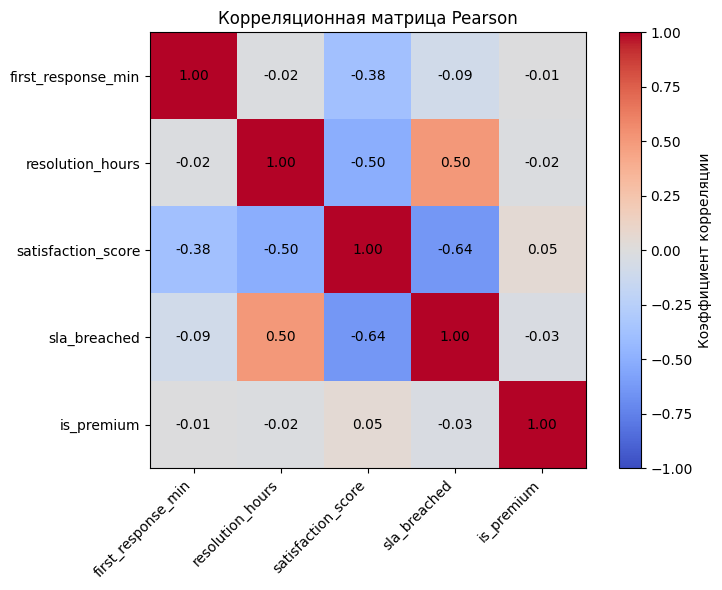

In [16]:
# Визуализируем корреляционную матрицу Pearson средствами matplotlib.
# Цвет показывает знак и силу связи, а числовые подписи внутри ячеек позволяют увидеть точное значение коэффициента.

# Создаём объект Figure и оси Axes — основной объектно-ориентированный способ построения графиков в matplotlib.
fig, ax = plt.subplots(figsize=(8, 6))
# Для корреляций фиксируем диапазон от -1 до 1. Благодаря этому цветовая шкала имеет единый смысл для всей матрицы.
image = ax.imshow(pearson_corr, vmin=-1, vmax=1, cmap="coolwarm")

ax.set_xticks(range(len(numeric_columns)))
ax.set_yticks(range(len(numeric_columns)))
ax.set_xticklabels(numeric_columns, rotation=45, ha="right")
ax.set_yticklabels(numeric_columns)
ax.set_title("Корреляционная матрица Pearson")

# Добавляем числовое значение коэффициента в каждую ячейку матрицы.
for row in range(len(numeric_columns)):
    for col in range(len(numeric_columns)):
        ax.text(
            col,
            row,
            f"{pearson_corr.iloc[row, col]:.2f}",
            ha="center",
            va="center",
        )

fig.colorbar(image, ax=ax, label="Коэффициент корреляции")
fig.tight_layout()
# Сохраняем график в PNG: dpi=150 задаёт достаточное учебное разрешение,
# bbox_inches='tight' уменьшает лишние поля вокруг изображения.
fig.savefig(FIGURES_DIR / "correlation_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

### Связь времени решения и оценки клиента

Построим диаграмму рассеяния и добавим линейный тренд только по строкам без пропусков.

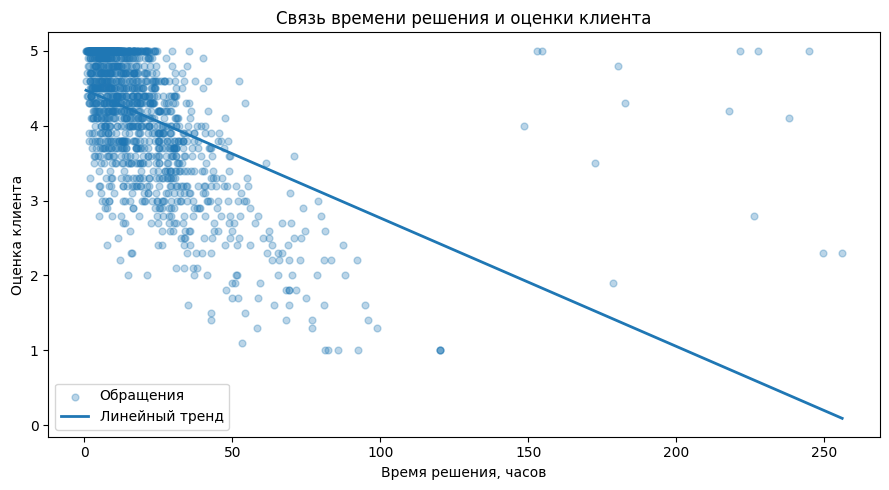

Наклон линии тренда: -0.0171


In [17]:
# Исследуем связь между временем решения и оценкой клиента.
# Для корректного scatter plot удаляем только строки, где отсутствует хотя бы один из двух анализируемых показателей.

scatter_data = analysis_data[
    ["resolution_hours", "satisfaction_score"]
].dropna()

# Преобразуем Series в NumPy-массивы для np.polyfit и np.linspace.
x = scatter_data["resolution_hours"].to_numpy()
y = scatter_data["satisfaction_score"].to_numpy()

fig, ax = plt.subplots(figsize=(9, 5))
# Небольшая прозрачность помогает видеть плотность точек при наложении.
ax.scatter(x, y, alpha=0.30, s=24, label="Обращения")

# np.polyfit(..., deg=1) оценивает прямую y = k*x + b.
# trend_slope — наклон k, trend_intercept — свободный b.
trend_slope, trend_intercept = np.polyfit(x, y, deg=1)
x_line = np.linspace(x.min(), x.max(), 200)
y_line = trend_slope * x_line + trend_intercept
ax.plot(x_line, y_line, linewidth=2, label="Линейный тренд")

ax.set_title("Связь времени решения и оценки клиента")
ax.set_xlabel("Время решения, часов")
ax.set_ylabel("Оценка клиента")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "resolution_vs_satisfaction.png", dpi=150, bbox_inches="tight")
plt.show()

print("Наклон линии тренда:", round(trend_slope, 4))

### Влияние выбросов на корреляцию

Сравним коэффициент на полном наборе и на данных без значений `resolution_hours > 140`. Это не означает, что выбросы обязательно нужно удалить: цель — увидеть чувствительность результата.

In [18]:
# Проверяем чувствительность корреляции к экстремально большим значениям.
# Сравниваем коэффициент на полном наборе и на данных без resolution_hours > 140.
# Это диагностический анализ, а не автоматическое основание удалять выбросы.

# Коэффициент на полном наборе данных.
full_corr = analysis_data[
    ["resolution_hours", "satisfaction_score"]
].corr().iloc[0, 1]

# Второй вариант временно исключает значения выше учебного порога 140 часов.
# Исходный DataFrame analysis_data при этом не изменяется.
without_outliers = analysis_data.loc[
    analysis_data["resolution_hours"] <= 140,
    ["resolution_hours", "satisfaction_score"],
]
without_outliers_corr = without_outliers.corr().iloc[0, 1]

corr_comparison = pd.DataFrame({
    "dataset": ["Все данные", "Без resolution_hours > 140"],
    "pearson_corr": [full_corr, without_outliers_corr],
})

display(corr_comparison)

,dataset,pearson_corr
0,Все данные,-0.502
1,Без resolution_hours > 140,-0.734


### Самостоятельный вывод

Ответьте:

1. Какой знак имеет связь времени решения и оценки?
2. Сильно ли меняется результат после исключения выбросов?
3. Почему фраза «долгое решение является единственной причиной низкой оценки» некорректна?

## 9. Групповой анализ и визуализация

Сравним каналы по числу обращений, оценке, времени решения и доле нарушений SLA.

In [19]:
# Строим агрегированную таблицу по каналам обслуживания.
# Для каждого канала считаем объём обращений, показатели удовлетворённости, время ответа/решения и долю нарушений SLA.

channel_summary = (
    analysis_data
    # Разбиваем обращения на группы по каналу обслуживания.
    .groupby("channel", as_index=False)
    .agg(
        # Число уникальных обращений в каждом канале.
        tickets_count=("ticket_id", "nunique"),
        avg_satisfaction=("satisfaction_score", "mean"),
        median_satisfaction=("satisfaction_score", "median"),
        avg_first_response_min=("first_response_min", "mean"),
        avg_resolution_hours=("resolution_hours", "mean"),
        # Среднее бинарного признака 0/1 = доля нарушений SLA.
        sla_breach_rate=("sla_breached", "mean"),
    )
    .sort_values("avg_satisfaction", ascending=False)
)

display(channel_summary)

,channel,tickets_count,avg_satisfaction,median_satisfaction,avg_first_response_min,avg_resolution_hours,sla_breach_rate
0,chat,544,4.508,4.800,5.511,20.487,0.351
2,phone,271,4.279,4.500,10.993,20.678,0.332
3,web_form,229,3.963,4.100,28.159,20.299,0.362
1,email,456,3.681,3.800,44.111,20.153,0.338


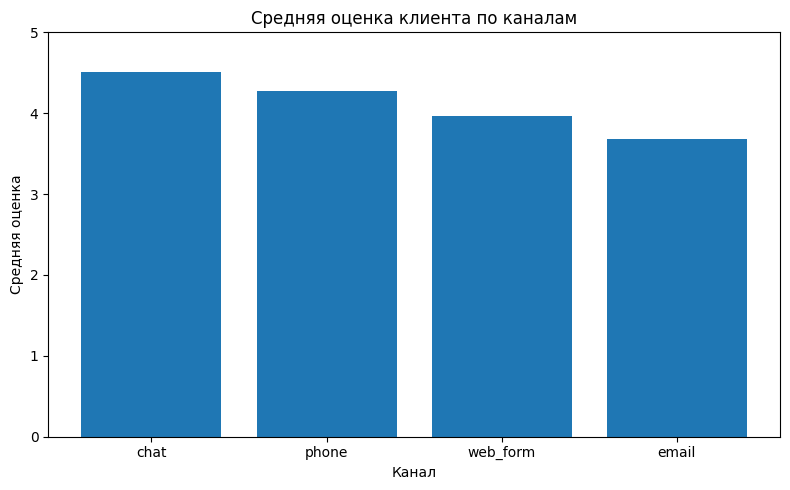

In [20]:
# Строим столбчатую диаграмму средней оценки по каналам.
# Фиксируем шкалу Y от 0 до 5, потому что satisfaction_score задан на пятибалльной шкале — так сравнение каналов интерпретируется корректнее.


fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(channel_summary["channel"], channel_summary["avg_satisfaction"])
ax.set_title("Средняя оценка клиента по каналам")
ax.set_xlabel("Канал")
ax.set_ylabel("Средняя оценка")
# Фиксируем естественные границы шкалы удовлетворённости.
ax.set_ylim(0, 5)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "channel_satisfaction.png", dpi=150, bbox_inches="tight")
plt.show()

### Распределение времени решения по приоритетам

Boxplot помогает увидеть медиану, разброс и выбросы. Средние значения следует интерпретировать вместе с распределением.

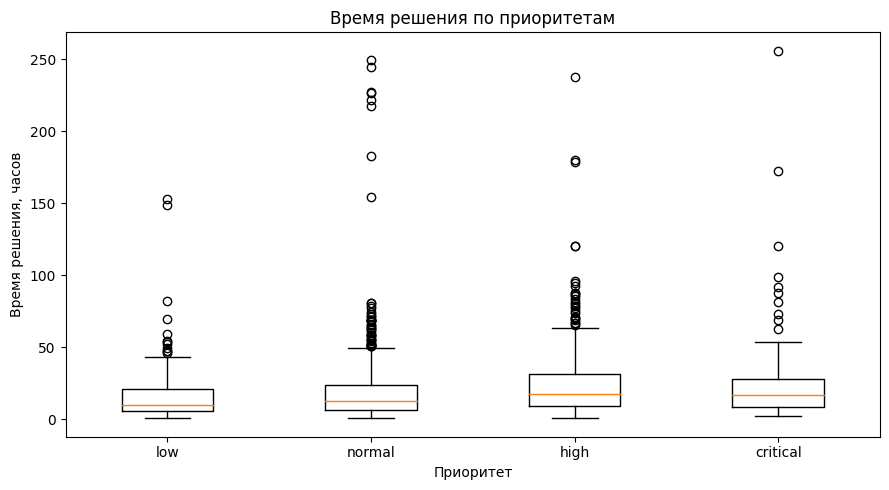

In [21]:
# Формируем boxplot времени решения по уровням приоритета.
# Подписи категорий задаём отдельно через set_xticks

# Явно задаём логический порядок приоритетов. Без этого категории могли бы отображаться в алфавитном порядке.
priority_order = ["low", "normal", "high", "critical"]
# Для каждого приоритета извлекаем отдельную Series времени решения и удаляем пропуски, поскольку boxplot ожидает числовые наблюдения.
priority_values = [
    analysis_data.loc[
        analysis_data["priority"] == priority,
        "resolution_hours",
    ].dropna()
    for priority in priority_order
]

fig, ax = plt.subplots(figsize=(9, 5))
# showfliers=True оставляет выбросы на графике — в статистическом анализе их важно видеть, а не скрывать автоматически.
ax.boxplot(priority_values, showfliers=True)
# Matplotlib нумерует группы boxplot начиная с 1. Подписи задаём отдельным вызовом set_xticks, чтобы код работал в разных версиях Matplotlib и в более новых.
ax.set_xticks(range(1, len(priority_order) + 1),priority_order)
ax.set_title("Время решения по приоритетам")
ax.set_xlabel("Приоритет")
ax.set_ylabel("Время решения, часов")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "resolution_by_priority.png", dpi=150, bbox_inches="tight")
plt.show()

### Самостоятельный шаг

Постройте аналогичную таблицу по полю `category`. Рассчитайте:

- количество обращений;
- среднее и медианное время решения;
- среднюю оценку;
- долю нарушений SLA.

Сравните категории `technical` и `refund` с остальными.

In [22]:
# Самостоятельный шаг: измените или расширьте агрегации при необходимости.

# Агрегируем данные по категориям обращений.
# Структура похожа на channel_summary, поэтому здесь закрепляется навык groupby + agg.
# Результат сортируем по среднему времени решения от большего к меньшему.
category_summary = (
    analysis_data
    # Группируем обращения по типу проблемы.
    .groupby("category", as_index=False)
    .agg(
        tickets_count=("ticket_id", "nunique"),
        avg_resolution_hours=("resolution_hours", "mean"),
        median_resolution_hours=("resolution_hours", "median"),
        avg_satisfaction=("satisfaction_score", "mean"),
        sla_breach_rate=("sla_breached", "mean"),
    )
    # Сверху окажутся категории с наибольшим средним временем решения.
    .sort_values("avg_resolution_hours", ascending=False)
)

display(category_summary)

,category,tickets_count,avg_resolution_hours,median_resolution_hours,avg_satisfaction,sla_breach_rate
4,refund,167,32.803,29.000,3.679,0.521
5,technical,386,30.443,23.750,3.754,0.495
1,delivery,269,21.919,17.300,4.091,0.398
3,payment,263,15.031,9.800,4.352,0.262
0,account,205,9.681,7.800,4.500,0.161
2,login,210,7.258,5.200,4.592,0.148


## 10. Тестирование статистических гипотез

Для двух независимых групп используем t-критерий Уэлча (`equal_var=False`). Он не требует считать дисперсии групп одинаковыми.

Правило интерпретации при уровне значимости `alpha = 0.05`:

- `p-value < 0.05` — есть основания отвергнуть H0;
- `p-value >= 0.05` — недостаточно оснований отвергнуть H0.

Не пишите «гипотеза доказана». Статистический тест оценивает согласованность наблюдаемых данных с H0.

In [23]:
# Задаём уровень статистической значимости alpha = 0.05.
# Функция ниже универсализирует t-критерий Уэлча для нескольких пар групп:
# очищает выборки, выполняет тест и возвращает компактный словарь для отчёта.

# Если p-value меньше 0.05, используем это как основание отвергнуть H0.

ALPHA = 0.05


def welch_ttest_report(
    sample_a: pd.Series,
    sample_b: pd.Series,
    label_a: str,
    label_b: str,
    metric: str,
) -> dict:
    """Выполнить t-test Уэлча и вернуть показатели для отчёта."""
    # На всякий случай приводим входные Series к числовому типу.
    # Некорректные значения становятся NaN и затем исключаются из теста.
    clean_a = pd.to_numeric(sample_a, errors="coerce").dropna()
    clean_b = pd.to_numeric(sample_b, errors="coerce").dropna()

    # equal_var=False включает вариант Уэлча, который не предполагает равенство дисперсий двух независимых групп.
    result = stats.ttest_ind(
        clean_a,
        clean_b,
        equal_var=False,
        nan_policy="omit",
    )

    # Возвращаем не только p-value, но и размер групп, средние, разность средних и текстовое статистическое решение.
    return {
        "metric": metric,
        "group_a": label_a,
        "group_b": label_b,
        "n_a": len(clean_a),
        "n_b": len(clean_b),
        "mean_a": clean_a.mean(),
        "mean_b": clean_b.mean(),
        "mean_difference_a_minus_b": clean_a.mean() - clean_b.mean(),
        "t_statistic": result.statistic,
        "p_value": result.pvalue,
        "alpha": ALPHA,
        "decision": (
            "Отвергаем H0"
            if result.pvalue < ALPHA
            else "Недостаточно оснований отвергнуть H0"
        ),
    }

### Гипотеза 1. Оценка в `chat` и `email`

- **H0:** средняя оценка клиентов в каналах `chat` и `email` не отличается.
- **H1:** средняя оценка клиентов в каналах `chat` и `email` отличается.

In [24]:
# Проверяем гипотезу о различии средней оценки между каналами chat и email.
# Сначала формируем две независимые выборки, затем передаём их в универсальную функцию welch_ttest_report().

chat_scores = analysis_data.loc[
    analysis_data["channel"] == "chat",
    "satisfaction_score",
]
email_scores = analysis_data.loc[
    analysis_data["channel"] == "email",
    "satisfaction_score",
]

# Передаём обе выборки в общую функцию статистического теста.
hypothesis_chat_email = welch_ttest_report(
    chat_scores,
    email_scores,
    label_a="chat",
    label_b="email",
    metric="satisfaction_score",
)

display(pd.DataFrame([hypothesis_chat_email]))

,metric,group_a,group_b,n_a,n_b,mean_a,mean_b,mean_difference_a_minus_b,t_statistic,p_value,alpha,decision
0,satisfaction_score,chat,email,522,441,4.508,3.681,0.827,15.731,0.000,0.050,Отвергаем H0


### Гипотеза 2. Время решения для `high` и `normal`

- **H0:** среднее время решения обращений с приоритетами `high` и `normal` не отличается.
- **H1:** среднее время решения обращений с приоритетами `high` и `normal` отличается.

In [25]:
# Проверяем гипотезу о различии среднего времени решения между обращениями с приоритетами high и normal.
# Логика полностью повторяет предыдущий статистический тест.

high_resolution = analysis_data.loc[
    analysis_data["priority"] == "high",
    "resolution_hours",
]
normal_resolution = analysis_data.loc[
    analysis_data["priority"] == "normal",
    "resolution_hours",
]

# Передаём обе выборки в общую функцию статистического теста.
hypothesis_high_normal = welch_ttest_report(
    high_resolution,
    normal_resolution,
    label_a="high",
    label_b="normal",
    metric="resolution_hours",
)

display(pd.DataFrame([hypothesis_high_normal]))

,metric,group_a,group_b,n_a,n_b,mean_a,mean_b,mean_difference_a_minus_b,t_statistic,p_value,alpha,decision
0,resolution_hours,high,normal,322,822,25.398,18.909,6.489,3.719,0.000,0.050,Отвергаем H0


### Гипотеза 3. Оценка при нарушенном и ненарушенном SLA

Выполните проверку по тому же шаблону.

- **H0:** средняя оценка при `sla_breached = 1` и `sla_breached = 0` не отличается.
- **H1:** средняя оценка различается.

In [26]:
# Проверяем гипотезу о различии средней оценки клиента при нарушенном SLA (1) и выполненном SLA (0).
# Сравниваются две независимые группы наблюдений.

sla_breached_scores = analysis_data.loc[
    analysis_data["sla_breached"] == 1,
    "satisfaction_score",
]
sla_ok_scores = analysis_data.loc[
    analysis_data["sla_breached"] == 0,
    "satisfaction_score",
]

# Передаём обе выборки в общую функцию статистического теста.
hypothesis_sla = welch_ttest_report(
    sla_breached_scores,
    sla_ok_scores,
    label_a="sla_breached",
    label_b="sla_ok",
    metric="satisfaction_score",
)

display(pd.DataFrame([hypothesis_sla]))

,metric,group_a,group_b,n_a,n_b,mean_a,mean_b,mean_difference_a_minus_b,t_statistic,p_value,alpha,decision
0,satisfaction_score,sla_breached,sla_ok,496,944,3.365,4.533,-1.168,-27.443,0.000,0.050,Отвергаем H0


### Сводная таблица гипотез

Помимо p-value обязательно сравнивайте размеры групп и средние значения. Статистическая значимость не заменяет содержательную интерпретацию величины различия.

In [27]:
# Объединяем результаты всех проверенных гипотез в одну таблицу.
# Это упрощает сравнение размеров выборок, средних, p-value и решений по H0, а также позволяет сохранить результаты одним CSV-файлом.

# Каждый результат функции — словарь с одинаковыми ключами, поэтому из списка словарей удобно построить единый DataFrame.
hypothesis_results = pd.DataFrame([
    hypothesis_chat_email,
    hypothesis_high_normal,
    hypothesis_sla,
])

display(hypothesis_results)

,metric,group_a,group_b,n_a,n_b,mean_a,mean_b,mean_difference_a_minus_b,t_statistic,p_value,alpha,decision
0,satisfaction_score,chat,email,522,441,4.508,3.681,0.827,15.731,0.000,0.050,Отвергаем H0
1,resolution_hours,high,normal,322,822,25.398,18.909,6.489,3.719,0.000,0.050,Отвергаем H0
2,satisfaction_score,sla_breached,sla_ok,496,944,3.365,4.533,-1.168,-27.443,0.000,0.050,Отвергаем H0


### Самостоятельная интерпретация

Для каждой гипотезы напишите:

1. какие группы сравнивались;
2. как различаются средние;
3. чему равен p-value;
4. какое решение принято относительно H0;
5. какое ограничение есть у вывода.

## 11. Подготовка временного ряда

Для прогнозирования порядок наблюдений критичен. Данные сортируются по времени, а train/test разделяются хронологически без перемешивания.

Сначала построим число уникальных обращений по календарным дням. Дни без обращений должны присутствовать в индексе и получать значение 0.

In [28]:
# Преобразуем данные обращений в дневной временной ряд.
# resample('D') создаёт календарную шкалу по дням, после чего считаем число обращений и дополнительные средние показатели для каждого дня.

daily_tickets = (
    analysis_data
    # Строки без даты нельзя корректно расположить на временной оси.
    .dropna(subset=["created_at"])
    .set_index("created_at")
    # D = daily: создаём дневные интервалы по календарю.
    .resample("D")
    .agg(
        tickets_count=("ticket_id", "nunique"),
        avg_satisfaction=("satisfaction_score", "mean"),
        avg_resolution_hours=("resolution_hours", "mean"),
        sla_breach_rate=("sla_breached", "mean"),
    )
)

# Если в конкретный календарный день обращений не было, заполняем количество нулём. Для счётчика используем целый тип.
daily_tickets["tickets_count"] = daily_tickets["tickets_count"].fillna(0).astype(int)
# 7-дневное скользящее среднее сглаживает краткосрочные колебания.
# min_periods=1 позволяет получить значение уже с первого дня ряда.
daily_tickets["rolling_mean_7d"] = (
    daily_tickets["tickets_count"].rolling(window=7, min_periods=1).mean()
)
daily_tickets["day_of_week"] = daily_tickets.index.day_name()
# dayofweek: понедельник=0, ..., воскресенье=6.
# Значения 5 и 6 соответствуют субботе и воскресенью.
daily_tickets["is_weekend"] = daily_tickets.index.dayofweek >= 5

print("Период:", daily_tickets.index.min().date(), "—", daily_tickets.index.max().date())
print("Количество календарных дней:", len(daily_tickets))
display(daily_tickets.head(10))

Период: 2026-03-01 — 2026-06-08
Количество календарных дней: 100


,tickets_count,avg_satisfaction,avg_resolution_hours,sla_breach_rate,rolling_mean_7d,day_of_week,is_weekend
created_at,,,,,,,
2026-03-01,4,4.475,10.950,0.250,4.000,Sunday,True
2026-03-02,8,4.083,14.350,0.375,6.000,Monday,False
2026-03-03,9,4.422,14.156,0.222,7.000,Tuesday,False
2026-03-04,11,4.809,10.100,0.000,8.000,Wednesday,False
2026-03-05,18,3.450,29.156,0.556,10.000,Thursday,False
2026-03-06,12,4.364,17.975,0.417,10.333,Friday,False
2026-03-07,10,4.389,13.080,0.300,10.286,Saturday,True
2026-03-08,3,3.833,16.667,0.333,10.143,Sunday,True
2026-03-09,12,3.983,16.425,0.583,10.714,Monday,False


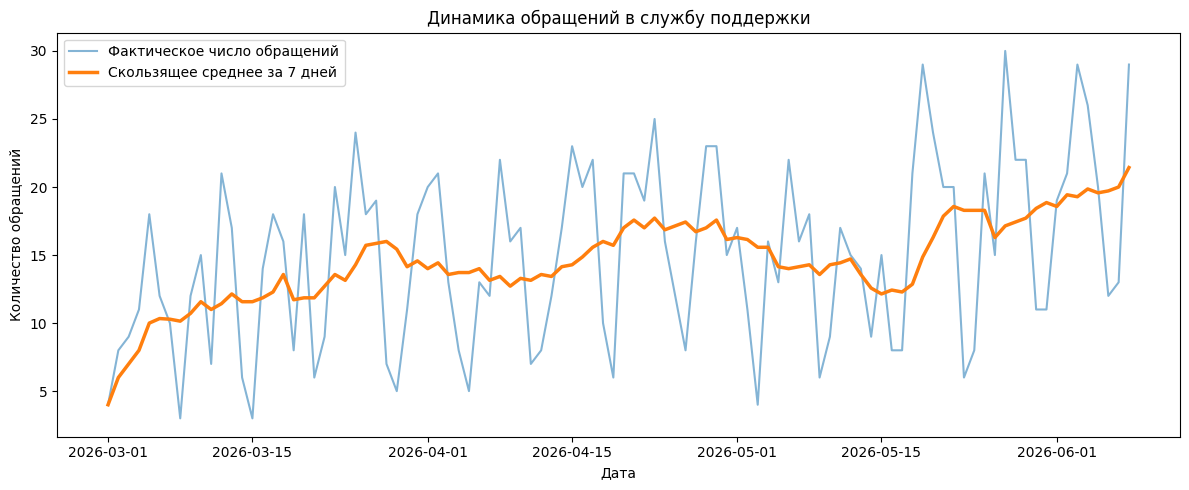

In [29]:
# Визуализируем исходный дневной ряд и его 7-дневное скользящее среднее.
# Скользящее среднее сглаживает ежедневный шум и помогает увидеть более устойчивую динамику нагрузки.

fig, ax = plt.subplots(figsize=(12, 5))
# Полупрозрачная линия показывает фактические дневные значения.
ax.plot(
    daily_tickets.index,
    daily_tickets["tickets_count"],
    alpha=0.55,
    label="Фактическое число обращений",
)

# Более толстая линия показывает сглаженную 7-дневную динамику.
ax.plot(
    daily_tickets.index,
    daily_tickets["rolling_mean_7d"],
    linewidth=2.5,
    label="Скользящее среднее за 7 дней",
)
ax.set_title("Динамика обращений в службу поддержки")
ax.set_xlabel("Дата")
ax.set_ylabel("Количество обращений")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "daily_tickets_timeseries.png", dpi=150, bbox_inches="tight")
plt.show()

### Проверка недельной сезонности и изменения нагрузки

Сравним будни и выходные, а также первую и вторую половины периода.

In [30]:
# Сравниваем нагрузку в будни и выходные, затем первую и вторую половины наблюдаемого периода. 
# Эти проверки помогают заметить недельную сезонность и возможное изменение общего уровня нагрузки.

weekday_weekend_summary = (
    daily_tickets
    # False = будний день, True = выходной.
    .groupby("is_weekend", as_index=False)
    .agg(
        days=("tickets_count", "size"),
        avg_tickets=("tickets_count", "mean"),
        median_tickets=("tickets_count", "median"),
    )
)
weekday_weekend_summary["period_type"] = weekday_weekend_summary["is_weekend"].map({
    False: "Будни",
    True: "Выходные",
})

display(weekday_weekend_summary[["period_type", "days", "avg_tickets", "median_tickets"]])

# Делим период пополам по позиции наблюдений, а не по значению даты.
midpoint = len(daily_tickets) // 2
first_half_mean = daily_tickets["tickets_count"].iloc[:midpoint].mean()
second_half_mean = daily_tickets["tickets_count"].iloc[midpoint:].mean()

print("Среднее в первой половине периода:", round(first_half_mean, 3))
print("Среднее во второй половине периода:", round(second_half_mean, 3))

,period_type,days,avg_tickets,median_tickets
0,Будни,71,17.972,18.000
1,Выходные,29,7.724,8.000


Среднее в первой половине периода: 13.08
Среднее во второй половине периода: 16.92


### Самостоятельный вывод

Опишите:

- различается ли нагрузка в будни и выходные;
- заметен ли рост нагрузки во второй половине периода;
- почему эти особенности важны для выбора прогноза.

## 12. Хронологическое разделение train/test

Последние 20% дней используем как тестовый период. Будущее не должно попадать в обучающую часть.

In [31]:
# Делим временной ряд на обучающую и тестовую части хронологически.
# Первые 80% дней используются как train, последние 20% — как test.
# Перемешивать временной ряд нельзя: модель не должна «видеть будущее».

time_series = daily_tickets["tickets_count"].astype(float)

# Индекс границы: примерно 80% наблюдений остаются в train.
split_index = int(len(time_series) * 0.80)
train = time_series.iloc[:split_index]
test = time_series.iloc[split_index:]

print("Train:", train.index.min().date(), "—", train.index.max().date(), len(train), "дней")
print("Test:", test.index.min().date(), "—", test.index.max().date(), len(test), "дней")

# Контроль утечки будущего: последняя дата train должна быть раньше первой даты test.
assert train.index.max() < test.index.min(), "Train и test разделены некорректно."

Train: 2026-03-01 — 2026-05-19 80 дней
Test: 2026-05-20 — 2026-06-08 20 дней


## 13. Базовые прогнозы

Сложную модель нужно сравнивать с простыми baseline-подходами:

1. **Last value** — каждый будущий день равен последнему наблюдению train;
2. **7-day mean** — каждый будущий день равен среднему за последние 7 дней train;
3. **Seasonal naive 7** — повторяется недельный рисунок последних 7 дней.

In [32]:
# Определяем метрики качества прогноза MAE и RMSE, затем строим три простых baseline-прогноза.
# Baseline нужен как минимальный ориентир: сложная модель должна давать качество не хуже простых правил.

def mae(actual: pd.Series, predicted: pd.Series) -> float:
    # MAE — среднее абсолютное отклонение прогноза от факта.
    # Метрика выражается в тех же единицах, что и целевой показатель.
    return float(np.mean(np.abs(actual.to_numpy() - predicted.to_numpy())))


def rmse(actual: pd.Series, predicted: pd.Series) -> float:
    # RMSE сильнее штрафует крупные ошибки благодаря возведению в квадрат.
    return float(np.sqrt(np.mean((actual.to_numpy() - predicted.to_numpy()) ** 2)))


# Baseline 1: прогнозируем на весь test последнее известное значение train.
last_value_forecast = pd.Series(train.iloc[-1], index=test.index, name="last_value")
# Baseline 2: используем одно постоянное значение — среднее за последние 7 дней обучающего периода.
mean_7_forecast = pd.Series(train.tail(7).mean(), index=test.index, name="mean_7")

# Baseline 3: повторяем недельный рисунок последних 7 дней train.
last_week_pattern = train.tail(7).to_numpy()
seasonal_values = np.resize(last_week_pattern, len(test))
seasonal_naive_forecast = pd.Series(
    seasonal_values,
    index=test.index,
    name="seasonal_naive_7",
)

# Собираем факт и все прогнозы в одну таблицу с единым индексом дат.
forecast_table = pd.DataFrame({
    "actual": test,
    "last_value": last_value_forecast,
    "mean_7": mean_7_forecast,
    "seasonal_naive_7": seasonal_naive_forecast,
})

display(forecast_table.head(10))

,actual,last_value,mean_7,seasonal_naive_7
created_at,,,,
2026-05-20,24.000,29.000,14.857,14.000
2026-05-21,20.000,29.000,14.857,9.000
2026-05-22,20.000,29.000,14.857,15.000
2026-05-23,6.000,29.000,14.857,8.000
2026-05-24,8.000,29.000,14.857,8.000
2026-05-25,21.000,29.000,14.857,21.000
2026-05-26,15.000,29.000,14.857,29.000
2026-05-27,30.000,29.000,14.857,14.000
2026-05-28,22.000,29.000,14.857,9.000


In [33]:
# Рассчитываем MAE и RMSE для каждого baseline.
# Чем меньше значение метрики, тем ближе прогноз к фактическим данным.
# Итоговую таблицу сортируем по MAE, чтобы лучший вариант был сверху.

# В список будем добавлять один словарь метрик на каждую модель.
baseline_metrics = []
for model_name in ["last_value", "mean_7", "seasonal_naive_7"]:
    baseline_metrics.append({
        "model": model_name,
        "MAE": mae(forecast_table["actual"], forecast_table[model_name]),
        "RMSE": rmse(forecast_table["actual"], forecast_table[model_name]),
    })

# Преобразуем список словарей в таблицу и сортируем от меньшей MAE к большей.
forecast_metrics = pd.DataFrame(baseline_metrics).sort_values("MAE")
display(forecast_metrics)

,model,MAE,RMSE
1,mean_7,6.907,7.994
2,seasonal_naive_7,7.400,9.083
0,last_value,10.150,12.172


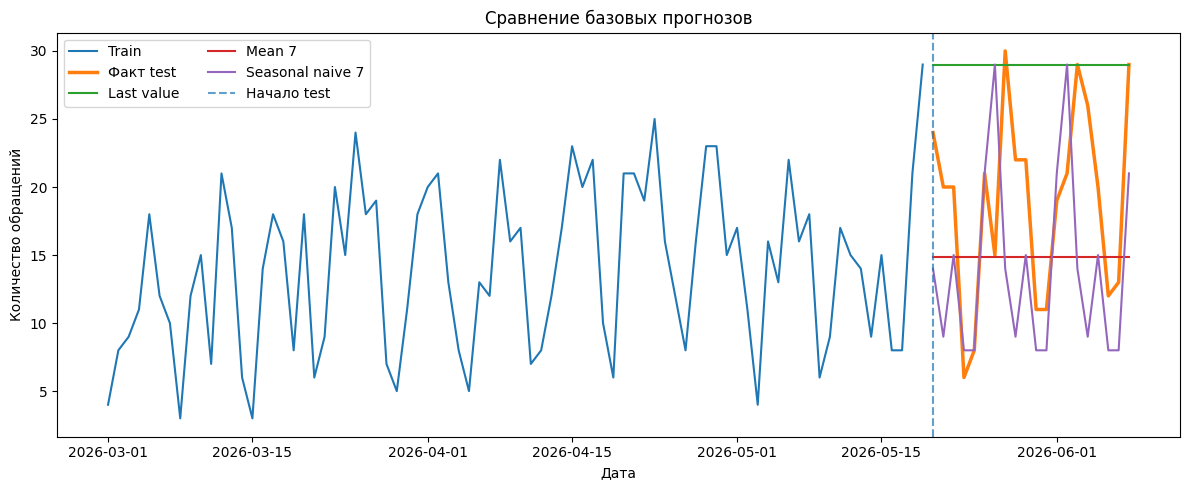

In [34]:
# Сравниваем фактический тестовый период с тремя baseline-прогнозами.
# Вертикальная пунктирная линия показывает границу между обучающим и тестовым временными интервалами.

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(train.index, train, label="Train")
ax.plot(test.index, test, linewidth=2.5, label="Факт test")
ax.plot(test.index, last_value_forecast, label="Last value")
ax.plot(test.index, mean_7_forecast, label="Mean 7")
ax.plot(test.index, seasonal_naive_forecast, label="Seasonal naive 7")
# Граница train/test помогает визуально не смешивать обучение и оценку прогноза.
ax.axvline(test.index.min(), linestyle="--", alpha=0.7, label="Начало test")
ax.set_title("Сравнение базовых прогнозов")
ax.set_xlabel("Дата")
ax.set_ylabel("Количество обращений")
ax.legend(ncol=2)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "baseline_forecasts.png", dpi=150, bbox_inches="tight")
plt.show()

### Самостоятельный вывод

Ответьте:

1. Какой baseline имеет минимальную MAE?
2. Совпадает ли лучший результат по MAE и RMSE?
3. Почему недельный seasonal naive может быть полезен для этого ряда?

## 14. Дополнительный блок: ARIMA

ARIMA рассматривается как расширение. Модель обучается только на train, затем прогнозирует длину test. Если `statsmodels` не установлена, ячейка не останавливает весь notebook и выводит инструкцию.

Параметры `(1, 1, 1)` используются как учебный стартовый вариант, а не как доказанно оптимальная спецификация.

In [35]:
# Дополнительный блок: строим ARIMA(1,1,1) только на train.
# Обработка исключений не позволяет необязательной модели остановить
# выполнение всего notebook, если statsmodels отсутствует или модель не сошлась.

# Значение None означает, что прогноз пока отсутствует.
# Это позволяет безопасно проверить результат в следующей ячейке.

arima_forecast = None
arima_status = "not_run"

try:
    from statsmodels.tsa.arima.model import ARIMA
    # ARIMA(1,1,1):
        # p=1 — один авторегрессионный лаг;
        # d=1 — одно дифференцирование;
        # q=1 — один лаг ошибки (moving average).
    arima_model = ARIMA(
        train,
        order=(1, 1, 1),
        enforce_stationarity=False,
        enforce_invertibility=False,
    )
    arima_fit = arima_model.fit()  # fit() оценивает параметры модели только по обучающей части.
    arima_forecast = arima_fit.forecast(steps=len(test)) # Прогнозируем ровно столько шагов, сколько наблюдений находится в test.
    arima_forecast.index = test.index
    arima_forecast.name = "arima_111"

    arima_metrics = pd.DataFrame([{
        "model": "arima_111",
        "MAE": mae(test, arima_forecast),
        "RMSE": rmse(test, arima_forecast),
    }])
    forecast_metrics = (
        pd.concat([forecast_metrics, arima_metrics], ignore_index=True)
        .sort_values("MAE")
        .reset_index(drop=True)
    )
    forecast_table["arima_111"] = arima_forecast
    arima_status = "success"

    display(forecast_metrics)
# Отдельно обрабатываем отсутствие библиотеки statsmodels.
except ImportError:
    arima_status = "statsmodels_not_installed"
    print(
        "ARIMA пропущена: statsmodels не установлена. "
        "Установите зависимости из requirements.txt и повторите ячейку."
    )

# Другие ошибки (например, проблемы с оцениванием модели) не должны останавливать оставшуюся часть работы.
except Exception as error:
    arima_status = f"error: {type(error).__name__}"
    print("ARIMA не построена:", error)

print("Статус ARIMA:", arima_status)

,model,MAE,RMSE
0,arima_111,6.711,7.898
1,mean_7,6.907,7.994
2,seasonal_naive_7,7.400,9.083
3,last_value,10.150,12.172


Статус ARIMA: success


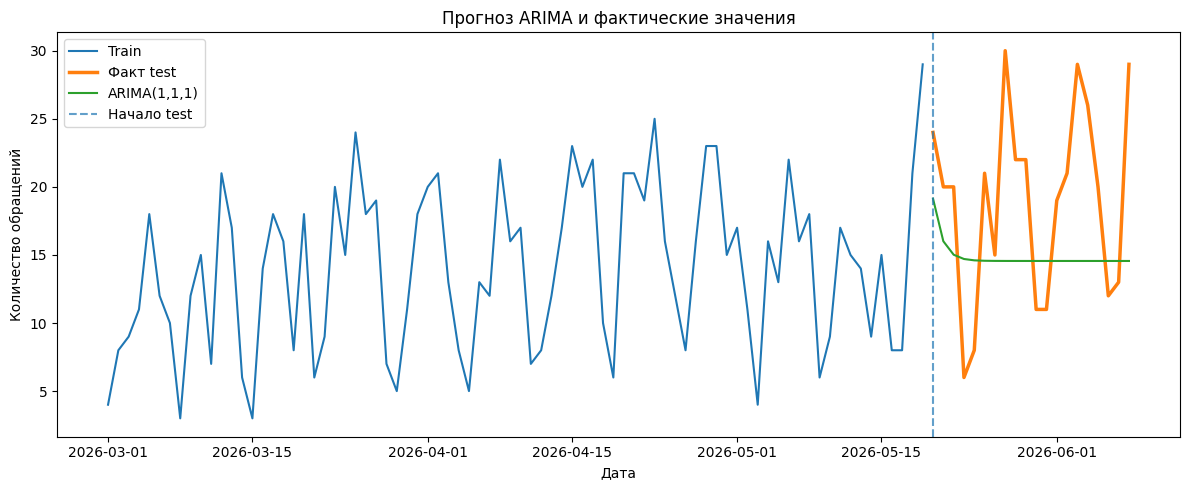

In [36]:
# Строим график ARIMA только в том случае, если прогноз успешно получен.
# Если предыдущая ячейка не смогла построить модель, выводим понятное сообщение вместо возникновения новой ошибки при обращении к отсутствующему прогнозу.

# Условие защищает код от обращения к несуществующему прогнозу.
if arima_forecast is not None:
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(train.index, train, label="Train")
    ax.plot(test.index, test, linewidth=2.5, label="Факт test")
    ax.plot(test.index, arima_forecast, label="ARIMA(1,1,1)")
    ax.axvline(test.index.min(), linestyle="--", alpha=0.7, label="Начало test")
    ax.set_title("Прогноз ARIMA и фактические значения")
    ax.set_xlabel("Дата")
    ax.set_ylabel("Количество обращений")
    ax.legend()
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / "arima_forecast.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("График ARIMA не построен, поскольку прогноз недоступен.")

### Интерпретация ARIMA

Сравните ARIMA с лучшим baseline. Более сложная модель полезна только тогда, когда она улучшает качество на отложенном временном периоде и остаётся содержательно объяснимой.

## 15. Сохранение результатов

Сохраняем таблицы в UTF-8 with BOM, чтобы кириллица корректно открывалась в большинстве табличных редакторов.

In [37]:
# Сохраняем основные результаты анализа в CSV.
# encoding='utf-8-sig' выбран для удобного открытия файлов с кириллицей в Excel и других распространённых табличных редакторах.

# Основная очищенная и объединённая таблица.
analysis_data.to_csv(
    OUTPUT_DIR / "support_analysis_dataset.csv",
    index=False,
    encoding="utf-8-sig",
)
# Сводка показателей по каналам.
channel_summary.to_csv(
    OUTPUT_DIR / "channel_summary.csv",
    index=False,
    encoding="utf-8-sig",
)
# Сводка показателей по категориям обращений.
category_summary.to_csv(
    OUTPUT_DIR / "category_summary.csv",
    index=False,
    encoding="utf-8-sig",
)
# Итоги статистических гипотез.
hypothesis_results.to_csv(
    OUTPUT_DIR / "hypothesis_results.csv",
    index=False,
    encoding="utf-8-sig",
)
# Дневной временной ряд.
daily_tickets.to_csv(
    OUTPUT_DIR / "daily_tickets.csv",
    encoding="utf-8-sig",
)
# Таблица метрик качества прогнозов.
forecast_metrics.to_csv(
    OUTPUT_DIR / "forecast_metrics.csv",
    index=False,
    encoding="utf-8-sig",
)
# Фактические и прогнозные значения по датам test.
forecast_table.to_csv(
    OUTPUT_DIR / "forecast_values.csv",
    encoding="utf-8-sig",
)

print("Сохранённые файлы:")
# rglob('*') рекурсивно обходит outputs и вложенные папки,
# чтобы показать пользователю все реально созданные файлы.
for file_path in sorted(OUTPUT_DIR.rglob("*")):
    if file_path.is_file():
        print("-", file_path.relative_to(PROJECT_ROOT))

Сохранённые файлы:
- outputs\category_summary.csv
- outputs\channel_summary.csv
- outputs\daily_tickets.csv
- outputs\figures\arima_forecast.png
- outputs\figures\baseline_forecasts.png
- outputs\figures\channel_satisfaction.png
- outputs\figures\correlation_matrix.png
- outputs\figures\daily_tickets_timeseries.png
- outputs\figures\resolution_by_priority.png
- outputs\figures\resolution_vs_satisfaction.png
- outputs\forecast_metrics.csv
- outputs\forecast_values.csv
- outputs\hypothesis_results.csv
- outputs\support_analysis_dataset.csv


## 16. Финальная техническая самопроверка

Следующая ячейка проверяет ключевые признаки завершённой работы.

In [38]:
# Выполняем финальную техническую самопроверку notebook.
# Каждое условие подтверждает важный признак корректного выполнения:
# от наличия файлов и качества merge до построения временного ряда и сохранения результата.

checks = {
    "Исходные файлы найдены": all(path.exists() for path in required_files.values()),
    "Повторные ticket_id удалены": analysis_data["ticket_id"].is_unique,
    "Дата преобразована": pd.api.types.is_datetime64_any_dtype(analysis_data["created_at"]),
    "После merge строки не размножились": len(analysis_data) == rows_before_merge,
    "Корреляционная матрица построена": pearson_corr.shape[0] == len(numeric_columns),
    "Проверено не менее двух гипотез": len(hypothesis_results) >= 2,
    "Временной ряд отсортирован": daily_tickets.index.is_monotonic_increasing,
    "Train находится раньше test": train.index.max() < test.index.min(),
    "Есть метрики прогнозов": not forecast_metrics.empty,
    "Итоговый датасет сохранён": (OUTPUT_DIR / "support_analysis_dataset.csv").exists(),
}

# Переводим словарь проверок в таблицу для удобного визуального контроля.
check_table = pd.DataFrame({
    "check": list(checks.keys()),
    "passed": list(checks.values()),
})
display(check_table)

# Если хотя бы одна обязательная проверка False, notebook останавливается с понятным сообщением — работа ещё не считается технически завершённой.
assert check_table["passed"].all(), "Некоторые контрольные проверки не пройдены."
print("Все обязательные технические проверки пройдены.")

,check,passed
0,Исходные файлы найдены,True
1,Повторные ticket_id удалены,True
2,Дата преобразована,True
3,После merge строки не размножились,True
4,Корреляционная матрица построена,True
5,Проверено не менее двух гипотез,True
6,Временной ряд отсортирован,True
7,Train находится раньше test,True
8,Есть метрики прогнозов,True
9,Итоговый датасет сохранён,True


Все обязательные технические проверки пройдены.


## 17. Итоговый аналитический вывод

Заполните этот блок своими словами.

### 1. Что анализировалось

Опишите предметную область, период и основные таблицы.

### 2. Какие проблемы качества обнаружены

Укажите дубли, пропуски, грязные категории, некорректные значения и выбросы. Объясните, как они были обработаны.

### 3. Какие взаимосвязи обнаружены

Опишите знак и примерную силу наиболее заметных связей. Не подменяйте корреляцию причинностью.

### 4. Какие гипотезы проверены

Для каждой гипотезы укажите группы, средние, p-value и решение относительно H0.

### 5. Что показал временной ряд

Опишите недельную сезонность, тренд и возможные всплески.

### 6. Какой прогноз оказался лучшим

Сравните модели по MAE и RMSE. Укажите, улучшила ли ARIMA результат относительно baseline.

### 7. Ограничения анализа

Например: синтетические данные, короткий период, отсутствие внешних факторов, учебные параметры ARIMA.

### 8. Следующий аналитический шаг

Предложите одно продолжение: сегментный прогноз, моделирование сезонности, анализ регионов или подготовку BI-дашборда.

## Контрольный чек-лист

- [ ] Notebook выполнен сверху вниз без ошибок.
- [ ] Исходные данные не изменялись напрямую.
- [ ] Использованы только относительные пути.
- [ ] Даты и категориальные поля очищены.
- [ ] После `merge` проверено количество строк.
- [ ] Корреляция интерпретирована без утверждения причинности.
- [ ] Для гипотез указаны H0, H1, p-value и решение.
- [ ] Train/test разделены хронологически.
- [ ] Сложный прогноз сравнивается с baseline.
- [ ] Таблицы и графики сохранены в `outputs`.
- [ ] Итоговый вывод содержит ограничения анализа.

## 18. Интеграция с Yandex DataLens

В этом блоке подготавливаются отдельные CSV-витрины для BI-анализа. DataLens используется не вместо Python, а как следующий слой: интерактивные чарты, селекторы, дашборды и объяснение результатов пользователям.

Рабочая цепочка:

```text
очистка и статистика в Python → DataLens-витрины → чарты → дашборд → аналитический вывод
```

Подробная пошаговая инструкция находится в `materials/datalens/student_datalens_guide.md`.

In [39]:
# Подготовка детальной витрины для Yandex DataLens
# Одна строка витрины соответствует одному обращению.
# Дополнительные поля создаются специально для фильтров, группировок, временных срезов, сегментации и визуальной проверки гипотез в BI.

# Выделяем отдельную папку для файлов, предназначенных именно для BI.
DATALENS_DIR = PROJECT_ROOT / "data" / "datalens"
DATALENS_DIR.mkdir(parents=True, exist_ok=True)

# Не меняем analysis_data: создаём отдельную копию для BI-преобразований.
datalens_support = analysis_data.copy()
# Календарная дата без времени удобна для дневных графиков и фильтров.
datalens_support["created_date"] = datalens_support["created_at"].dt.date.astype(str)
# Начало недели рассчитываем как понедельник соответствующей недели.
datalens_support["week_start"] = (
    datalens_support["created_at"]
    - pd.to_timedelta(datalens_support["created_at"].dt.dayofweek, unit="D")
).dt.normalize().dt.date.astype(str)
# Начало месяца удобно использовать как стабильное измерение для месячной агрегации.
datalens_support["month_start"] = datalens_support["created_at"].dt.to_period("M").dt.start_time.dt.date.astype(str)
datalens_support["hour"] = datalens_support["created_at"].dt.hour
datalens_support["weekday_number"] = datalens_support["created_at"].dt.dayofweek + 1
# Создаём русские подписи дней недели для человекочитаемых чартов.
weekday_ru = {0:"Понедельник",1:"Вторник",2:"Среда",3:"Четверг",4:"Пятница",5:"Суббота",6:"Воскресенье"}
datalens_support["weekday_name"] = datalens_support["created_at"].dt.dayofweek.map(weekday_ru)
datalens_support["is_weekend"] = (datalens_support["created_at"].dt.dayofweek >= 5).astype(int)
# Находим середину всего временного интервала и создаём признак, позволяющий сравнивать первую и вторую половины периода.
mid_date = datalens_support["created_at"].min() + (
    datalens_support["created_at"].max() - datalens_support["created_at"].min()
) / 2
datalens_support["period_part"] = np.where(
    datalens_support["created_at"] < mid_date, "Первая половина", "Вторая половина"
)
# record_count=1 позволяет в BI считать количество строк через SUM(record_count).
datalens_support["record_count"] = 1
datalens_support["sla_status"] = np.where(
    datalens_support["sla_breached"].eq(1), "SLA нарушен", "SLA выполнен"
)
# Разбиваем числовую оценку на интервальные категории,
# чтобы строить распределения и фильтры без сложных вычисляемых полей в BI.
datalens_support["satisfaction_band"] = pd.cut(
    datalens_support["satisfaction_score"], [-np.inf, 3, 4.5, np.inf],
    labels=["Низкая", "Средняя", "Высокая"], right=False,
).astype("string")
# Создаём интервалы времени первого ответа.
datalens_support["first_response_bucket"] = pd.cut(
    datalens_support["first_response_min"], [-np.inf, 5, 15, 30, 60, np.inf],
    labels=["До 5 мин", "5–15 мин", "15–30 мин", "30–60 мин", "Более 60 мин"], right=False,
).astype("string")
# Аналогично группируем время полного решения обращения.
datalens_support["resolution_bucket"] = pd.cut(
    datalens_support["resolution_hours"], [-np.inf, 8, 24, 48, 72, np.inf],
    labels=["До 8 ч", "8–24 ч", "24–48 ч", "48–72 ч", "Более 72 ч"], right=False,
).astype("string")
# Отдельные признаки ниже упрощают фильтрацию именно тех групп,
# которые использовались в статистических гипотезах.
datalens_support["channel_hypothesis_group"] = np.where(
    datalens_support["channel"].isin(["chat", "email"]), datalens_support["channel"], "other"
)
datalens_support["priority_hypothesis_group"] = np.where(
    datalens_support["priority"].isin(["high", "normal"]), datalens_support["priority"], "other"
)
datalens_support["sla_hypothesis_group"] = np.where(
    datalens_support["sla_breached"].eq(1), "sla_breached", "sla_ok"
)
# Перед экспортом переводим datetime в стабильное строковое представление,
# понятное при загрузке CSV в BI-сервис.
datalens_support["created_at"] = datalens_support["created_at"].dt.strftime("%Y-%m-%d %H:%M:%S")
if pd.api.types.is_datetime64_any_dtype(datalens_support["registration_date"]):
    datalens_support["registration_date"] = datalens_support["registration_date"].dt.date.astype(str)

# Сохраняем основную детальную витрину: одна строка = одно обращение.
datalens_support.to_csv(
    DATALENS_DIR / "support_service_datalens.csv", index=False, encoding="utf-8-sig"
)
print("Детальная витрина:", datalens_support.shape)


Детальная витрина: (1500, 36)


In [40]:
# Подготавливаем дополнительные витрины для DataLens:
# 1) дневной временной ряд с прогнозами и ошибками;
# 2) сводку статистических гипотез с размером эффекта;
# 3) таблицу метрик качества прогнозов в «длинном» формате.

# Дневная витрина, статистические гипотезы и метрики прогнозов
# math нужен для квадратного корня при ручном расчёте Cohen's d.
import math

# Возвращаем дату из индекса в обычный столбец — BI-сервису так удобнее работать.
datalens_daily = daily_tickets.reset_index().rename(columns={"created_at": "created_date"})
datalens_daily["created_date"] = pd.to_datetime(datalens_daily["created_date"])
# Подготавливаем таблицу прогнозов к объединению по календарной дате.
forecast_export = forecast_table.reset_index().rename(columns={"created_at": "created_date", "index": "created_date"})
forecast_export["created_date"] = pd.to_datetime(forecast_export["created_date"])
# Добавляем прогнозные значения только там, где для даты они существуют.
datalens_daily = datalens_daily.merge(forecast_export, on="created_date", how="left")
# В forecast_table фактическое поле actual заполнено только для test,
# поэтому его наличие используем как признак принадлежности даты к test.
datalens_daily["dataset_part"] = np.where(datalens_daily["actual"].notna(), "test", "train")
# Для каждой доступной модели считаем абсолютную ошибку по датам test.
# Если ARIMA не строилась, соответствующего столбца просто не будет.
for model_name in ["last_value", "mean_7", "seasonal_naive_7", "arima_111"]:
    if model_name in datalens_daily:
        datalens_daily[f"abs_error_{model_name}"] = np.where(
            datalens_daily["actual"].notna() & datalens_daily[model_name].notna(),
            (datalens_daily["actual"] - datalens_daily[model_name]).abs(),
            np.nan,
        )
datalens_daily["week_start"] = (
    datalens_daily["created_date"]
    - pd.to_timedelta(datalens_daily["created_date"].dt.dayofweek, unit="D")
).dt.normalize().dt.date.astype(str)
datalens_daily["weekday_number"] = datalens_daily["created_date"].dt.dayofweek + 1
datalens_daily["weekday_name"] = datalens_daily["created_date"].dt.dayofweek.map(weekday_ru)
datalens_daily["created_date"] = datalens_daily["created_date"].dt.date.astype(str)
datalens_daily.to_csv(
    DATALENS_DIR / "daily_forecast_datalens.csv", index=False, encoding="utf-8-sig"
)

# Cohen's d показывает стандартизированный размер различия средних.
# В отличие от p-value, он помогает оценить практическую величину эффекта.
def cohens_d_for_export(x, y):
    x, y = pd.Series(x).dropna().astype(float), pd.Series(y).dropna().astype(float)
    # pooled — объединённое стандартное отклонение двух независимых групп.
    pooled = math.sqrt(((len(x)-1)*x.var(ddof=1) + (len(y)-1)*y.var(ddof=1)) / (len(x)+len(y)-2))
    return (x.mean() - y.mean()) / pooled

# Описываем три гипотезы декларативно: название, вопрос, метрика,
# поле группировки, значения групп и подписи для выгрузки.
hypothesis_specs = [
    ("H1", "Средняя оценка: chat против email", "Отличается ли средняя оценка клиента между chat и email?", "satisfaction_score", "channel", ["chat", "email"], ["chat", "email"]),
    ("H2", "Время решения: high против normal", "Отличается ли среднее время решения между high и normal?", "resolution_hours", "priority", ["high", "normal"], ["high", "normal"]),
    ("H3", "Оценка: SLA нарушен против выполнен", "Отличается ли оценка при нарушенном и выполненном SLA?", "satisfaction_score", "sla_breached", [1, 0], ["sla_breached", "sla_ok"]),
]
hypothesis_rows = []
# Для каждой гипотезы повторно формируем описательные статистики,
# чтобы BI-таблица содержала данные для обеих сравниваемых групп.
for index, (hid, title, question, metric, group_field, group_values, labels) in enumerate(hypothesis_specs):
    samples = [analysis_data.loc[analysis_data[group_field] == value, metric].dropna() for value in group_values]
    effect = cohens_d_for_export(samples[0], samples[1])
    result_row = hypothesis_results.iloc[index]
    # Интерпретируем абсолютное значение Cohen's d по учебным порогам.
    magnitude = "Большой" if abs(effect) >= 0.8 else "Средний" if abs(effect) >= 0.5 else "Малый" if abs(effect) >= 0.2 else "Очень малый"
    for order, (label, values) in enumerate(zip(labels, samples), start=1):
        hypothesis_rows.append({
            "hypothesis_id": hid,
            "hypothesis_title": title,
            "question": question,
            "metric": metric,
            "group_name": label,
            "sample_size": len(values),
            "mean_value": values.mean(),
            "median_value": values.median(),
            "std_value": values.std(ddof=1),
            "min_value": values.min(),
            "max_value": values.max(),
            "p_value": result_row["p_value"],
            "alpha": result_row["alpha"],
            "statistically_significant": "Да" if result_row["p_value"] < result_row["alpha"] else "Нет",
            "decision": result_row["decision"],
            "mean_difference_a_minus_b": result_row["mean_difference_a_minus_b"],
            "cohens_d_a_minus_b": effect,
            "effect_magnitude": magnitude,
            "group_order": order,
        })

# Итог: по две строки на гипотезу — одна для каждой сравниваемой группы.
hypothesis_summary_datalens = pd.DataFrame(hypothesis_rows)
hypothesis_summary_datalens.to_csv(
    DATALENS_DIR / "hypothesis_summary_datalens.csv", index=False, encoding="utf-8-sig"
)

# melt переводит таблицу из широкого формата (MAE, RMSE отдельными столбцами)
# в длинный формат model | metric | value — он удобнее для BI-визуализаций.
forecast_metrics_datalens = forecast_metrics.melt(
    id_vars="model", var_name="metric", value_name="value"
)
forecast_metrics_datalens.to_csv(
    DATALENS_DIR / "forecast_metrics_datalens.csv", index=False, encoding="utf-8-sig"
)

print("Дневная витрина:", datalens_daily.shape)
print("Сводка гипотез:", hypothesis_summary_datalens.shape)
print("Метрики прогнозов:", forecast_metrics_datalens.shape)


Дневная витрина: (100, 21)
Сводка гипотез: (6, 19)
Метрики прогнозов: (8, 3)


### Гипотезы через чарты

DataLens помогает увидеть различие и сформулировать вопрос, но график не заменяет статистический тест. Для каждой гипотезы на дашборде покажите:

1. средние значения групп;
2. размер каждой группы;
3. p-value, рассчитанный в Python;
4. практическую величину различия;
5. ограничение причинной интерпретации.

При изменении селекторов статистический тест для нового среза нужно пересчитать в Python.

In [41]:
# Проверяем готовность всех CSV-витрин для загрузки в DataLens.
# Помимо существования файлов контролируем уникальность ticket_id:
# одна строка детальной витрины должна соответствовать одному обращению.

datalens_checks = {
    "Детальная витрина создана": (DATALENS_DIR / "support_service_datalens.csv").exists(),
    "Дневная витрина создана": (DATALENS_DIR / "daily_forecast_datalens.csv").exists(),
    "Сводка гипотез создана": (DATALENS_DIR / "hypothesis_summary_datalens.csv").exists(),
    "Метрики прогнозов созданы": (DATALENS_DIR / "forecast_metrics_datalens.csv").exists(),
    "Одна строка детальной витрины соответствует обращению": datalens_support["ticket_id"].is_unique,
}

# Представляем словарь проверок как таблицу True/False.
display(pd.DataFrame({"check": datalens_checks.keys(), "passed": datalens_checks.values()}))
# Останавливаем выполнение, если хотя бы одна витрина не создана
# или нарушено требование уникальности обращений.
assert all(datalens_checks.values()), "Не все DataLens-витрины готовы."
print("DataLens-витрины готовы к загрузке.")

,check,passed
0,Детальная витрина создана,True
1,Дневная витрина создана,True
2,Сводка гипотез создана,True
3,Метрики прогнозов созданы,True
4,Одна строка детальной витрины соответствует об...,True


DataLens-витрины готовы к загрузке.


### Что собрать в DataLens

- операционный обзор с четырьмя KPI;
- динамику обращений;
- сравнение каналов и категорий;
- точечный чарт времени решения и оценки;
- лабораторию трёх гипотез;
- сравнение прогнозов по MAE и RMSE;
- селекторы периода, региона, канала и категории.

Используйте чек-лист `materials/datalens/datalens_qa_checklist.md`.